# Вычислительная математика
## 5.3 УРЧП. Параболический тип

Содержание семинара:

- __Общая формулировка УРЧП (напоминание)__
    - Линейные УРЧП. Классификация
    - Об отличиях типов
- __Дискретизация параболической задачи (на примере уравнения диффузии)__
    - Одномерный случай (по координате)
        - Постоянные коэффициенты
        - Метод прогонки (на примере схемы Кранка-Никольсон)
        - Переменные коэффициенты (консерватизм)
        - Квазилинейный случай (неоднородный)
    - Многомерный случай (по координате)
- __Сходимость численных схем (параболика)__
    - Сходимость = Аппроксимация + Устойчивость
    - Примеры исследования на устойчивость многомерных схем спектральным признаком
    - Пример исследования на аппроксимацию схемы расщепления по направлению
- __Домашнее задание__

## Общая формулировка УРЧП (напоминание)
### Линейные УРЧП. Классификация

__Определение.__ __Линейное УРЧП__ от двух переменных это уравнение вида

$$
A(x, y) \frac{\partial^2 u}{\partial x^2}+B(x, y) \frac{\partial^2 u}{\partial x \partial y}+C(x, y) \frac{\partial^2 u}{\partial y^2}+D(x, y) \frac{\partial u}{\partial x}+E(x, y) \frac{\partial u}{\partial y}+F(x, y) u+G(x, y)=0
$$

что эквивалентно следующей записи

$$
A(x, y) \frac{\partial^2 u}{\partial x^2}+B(x, y) \frac{\partial^2 u}{\partial x \partial y}+C(x, y) \frac{\partial^2 u}{\partial y^2}=\hat{\mathbf{L}} u
$$

Цель - __найти $u(x,y)$ с заданными граничными условиями__.

__Примечание.__ Если бы какие-то из коэффициентов зависели бы ещё дополнительно от $u$, $\frac{\partial u}{\partial x}$ или $\frac{\partial u}{\partial y}$, то уравнение называлось бы __квазилинейным__.

Относительно $A(x, y), B(x, y)$ и $C(x, y)$ можно подвести следующую классификацию УРЧП:

$$
\begin{array}{|c|c|c|}
\hline \text { Classification } & \text { Condition } & \text { Example of PDE } \\
\hline \text { Parabolic } & B^2-4 A C=0 & \text { Heat equation } \\
\hline \text { Hyperbolic } & B^2-4 A C>0 & \text { Wave equation } \\
\hline \text { Elliptic } & B^2-4 A C<0 & \text { Laplace equation } \\
\hline \begin{array}{c}
\text { Mix Type } \\
\text { (parabolic/hyperbolic/elliptic) }
\end{array} & \begin{array}{c}
\text { Satisfied all/more than one of the } \\
\text { above conditions }
\end{array} & \begin{array}{c}
\text { Heat/Wave/Laplace/Poisson } \\
\text { equation }
\end{array} \\
\hline
\end{array}
$$

__Примечание.__ Классификация __локальна__, т.к. коэффициенты зависят от точки плоскости в которой мы сейчас находимся, и знак Condition может меняться в рассматриваемой области - отсюда и смешанный тип.

__Примечание.__ Названия типов формально берутся от квадратичной формы характеристического уравнения. Все типа существенно различаются по свойствам, что приводит к их отдельному рассмотрению. В частности, решения эллиптического уравнения всегда гладкие, тогда как решения гиперболических уравнений этим свойством не обладают.

__Примечание.__ В случае бОльшего числа переменных, типы сохраняются:

$$\sum_{i=1}^n \sum_{j=1}^n a_{i, j} \frac{\partial^2 u}{\partial x_i \partial x_j} \; + \; F(u,\; \frac{\partial u}{\partial x_1},\; \frac{\partial u}{\partial x_2}, \cdots, \; \frac{\partial u}{\partial x_n})=0$$

- __Elliptic__: All eigenvalues $a_{i,j}$ have the same sign. [Laplace-Eq.]
- __Parabolic__: One eigenvalue is zero. [Diffusion-Eq.]
- __Hyperbolic__: One eigenvalue has opposite sign. [Wave-Eq.]
- __Ultrahyperbolic__: More than one positive and negative eigenvalue.
- __Mixed__

### Об отличиях типов

__Эллиптический тип__
- Обычно нет временной зависимости - несколько пространственных координат. Нет эволюции во времени - процесс __стационарный__.
- Решаются как краевые задачи при заданных краевых условиях.
- Решения гладкие, если позволяют краевые условия.

Примеры:

- Уравнение Пуассона (Лапласа при $f=0$):
$$
\sum_{i=1}^n \frac{\partial^2}{\partial x_i^2} u(x)=f(x)
$$

__Параболический тип__
- Явный __эволюционный во времени__ процесс. См. характеристики для понимания. Нулевое собственное число отвечает времени.
- Явная зависимость от времени.
- Решаются как при заданных начальных условиях, так и при краевых.
- "Негладкости" и "разрывы" возможны, но __сглаживаются__ со временем.

Примеры:

- Уравнение теплопроводности (диффузии)

$$
\frac{\partial u}{\partial t}-a^2 \Delta u=f(\mathbf{r}, t)
$$

- Уравнение анизотропной диффузии (квазилинейное - страшно, да?)

$$
\frac{\partial u(\mathbf{r}, t)}{\partial t}=\sum_{i=1}^3 \sum_{j=1}^3 \frac{\partial}{\partial x_i}\left[D_{i j}(u, \mathbf{r}) \frac{\partial u(\mathbf{r}, t)}{\partial x_j}\right]
$$

__Гиперболический тип__

- Также эволюционный во времени процесс, но можно страктовать отрицательное с.з. как обратное время.
- Решаются как при заданных начальных условиях, так и при краевых.
- "Негладкости" и "разрывы" могут __появляться__ в ходе эволюции (ударная волна).

Примеры:

- Волновое уравнение

$$
\left(\Delta-\frac{1}{c^2} \frac{\partial^2}{\partial t^2}\right) u=0
$$

__Примечание.__ Отличия могут показаться несущественными, но на практике они столь велики, что решения каждого типа считается отдельной областью. В этом семинаре рассмотрим подробнее параболический тип.

## Дискретизация параболической задачи (на примере уравнения диффузии)

### Одномерный (по координате) случай

__Определение.__ Задача уравнения диффузии (теплопроводности) ставится следующим образом:

$$
\frac{\partial u}{\partial t}=a \frac{\partial^2 u}{\partial x^2}+f(t, x), \quad t \in[0, \mathrm{~T}], \quad x \in[0, X]
$$

В линейном случае $a=a(x, t)>0$. В квазилинейном случае $a=a(u, x, t)>0$ и $f=f(u, x, t)$.

Для того, чтобы задача была поставлена корректно, необходимо задать __начальное условие__ по времени:

$$
u(0, x)=u_0(x), \quad t=0
$$

и __граничные условия__ (в одном из трёх родов) по координате:

Условия первого рода:
$$
\begin{aligned}
& u=\varphi_1(t), \quad x=0 \\
& u=\varphi_2(t), \quad x=X
\end{aligned}
$$
и условия второго рода:
$$
\begin{aligned}
& -\frac{\partial u}{\partial x}=\varphi_1(t), \quad x=0 \\
& \frac{\partial u}{\partial x}=\varphi_2(t), \quad x=X
\end{aligned}
$$
Условия третьего рода:
$$
\begin{aligned}
& -A_1 \frac{\partial u}{\partial x}+B_1 u=\varphi_1(t), \quad x=0 \\
& A_2 \frac{\partial u}{\partial x}+B_2 u=\varphi_2(t), \quad x=X 
\end{aligned}
$$

### Схемы для постоянных коэффициентов для уравнения

Приведём некоторые схемы, работающие для константного $a$. 

- __Явная схема__

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=a \cdot \frac{u_{m-1}^n-2 u_m^n+u_{m+1}^n}{h^2}+f_m^n
$$

Устойчива при $\sigma=\frac{a \tau}{h^2} \leq \frac{1}{2}$ и порядок аппроксимации $O\left(\tau, h^2\right)$.

![original image](https://cdn.mathpix.com/snip/images/xtiCm2IM3BHT7wxj_SwQWxeVx7PsSpfkREDDfd8HTa0.original.fullsize.png)



- __Неявная схема__

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=a \frac{u_{m-1}^{n+1}-2 u_m^{n+1}+u_{m+1}^{n+1}}{h^2}+f_m^n
$$

Устойчива при при любых $\tau, h$, порядок аппроксимации $O\left(\tau, h^2\right)$.

![original image](https://cdn.mathpix.com/snip/images/x-G5iQxJhtFoTRAHR4oye8L7TUqmAhxhvskt1tfE934.original.fullsize.png)


- __Смешанная шеститочечная схема__

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=a\left[\xi \frac{u_{m-1}^{n+1}-2 u_m^{n+1}+u_{m+1}^{n+1}}{h^2}+(1-\xi) \frac{u_{m-1}^n-2 u_m^n+u_{m+1}^n}{h^2}\right]+f_m^n
$$

Где вес $\xi \in[0,1]$ - заранее задаваемое нами число - отвечает за смесь явной и неявной производных по координате. Определяется эмпирически или ищется наиболее оптимальное значение $\xi$ можно отыскать из "максимизации" устойчивости (об этом позже).

![original image](https://cdn.mathpix.com/snip/images/L6KyBzKOYwWPUSTUICIjVHedMdrTpnWhm7hh8J0jj18.original.fullsize.png)


- __Схема Кранка-Никольсон__ - смешанная схема при $\xi =\frac{1}{2}$

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=\frac{a}{2}\left(\frac{u_{m-1}^{n+1}-2 u_m^{n+1}+u_{m+1}^{n+1}}{h^2}+\frac{u_{m-1}^n-2 u_m^n+u_{m+1}^n}{h^2}\right)+f_m^n
$$

Схема устойчива при любых шагах $\tau, h$ и имеет порядок аппроксимации $O\left(\tau, h^2\right)$. Эта схема, в отличие от двух предыдущих, __не является монотонной__, т.е. она может давать осцилляции разностного происхождения на решениях, имеющих большие градиенты.

- __Трёхслойная схема__ - вводим "смесь" явной и неявной схемы также для производной по времени

$$
\begin{aligned}
& \frac{(1-\eta)\left(u_m^{n+1}-u_m^n\right)}{\tau}-\eta \frac{u_m^n-u_m^{n-1}}{\tau}- \\
& -a\left[(1-\xi) \frac{u_{m-1}^n-2 u_m^n+u_{m+1}^n}{h^2}+\xi \frac{u_{m-1}^{n+1}-2 u_m^{n+1}+u_{m+1}^{n+1}}{h^2}\right]=f_m^n
\end{aligned}
$$

При $\eta=0,5, \quad \xi=1 \quad$ ее порядок аппроксимации равен $O\left(\tau^2, h^2\right)$. Недостатком схемы является более высокий порядок разностного уравнения по времени, чем порядок исходного дифференциального, следовательно, необходимость ставить дополнительное условие на $u_t^{\prime}(0, x)$.

![original image](https://cdn.mathpix.com/snip/images/1KchTxOdnkBI81jS9fpI3uTPFT91AAENfY-gWSDdRTE.original.fullsize.png)

__Примечание.__ Неявные схемы решаются путём построения СЛАУ на все пространственные точки в новом слое.

__Примечание.__ Эти схемы легко перенести на многомерный случай или на любое другое параболическое уравнение. Главное помнить, что они "хорошо" работают только __при постоянных коэффициентах__. Если коэффициенты зависят от времени и координат, то их строят исходя из нужных законов сохранения.

КОД с примером явной схемы

КОД с примером Кранка-Николсон

In [2]:
# Пример явной схемы f = 0

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Parameters
a = 1.0
L = 1.0
T = 0.2
Nx = 100
Nt = 100000
h = L/(Nx-1)
tau = T/(Nt-1)
x = np.linspace(0, L, Nx)
t = np.linspace(0, T, Nt)

# Initial and boundary conditions
def u0(x):
    return  1 + np.sin(2*np.pi*x/L)**2 + np.sin(np.pi*x/L)

def ul(t):
    return 1

def ur(t):
    return 1

# Finite difference method
r = a*tau/h**2
u = np.zeros((Nx, Nt))
 
u[:, 0] = u0(x)

for n in range(Nt-1):
    
    u[0, n+1] = ul(t[n+1])
    u[-1, n+1] = ur(t[n+1])
    
    for m in range(1, Nx-1):
        u[m, n+1] = u[m, n] + r*(u[m-1, n] - 2*u[m, n] + u[m+1, n]) 

/tmp/ipykernel_330/3408235886.py:12: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(sm)


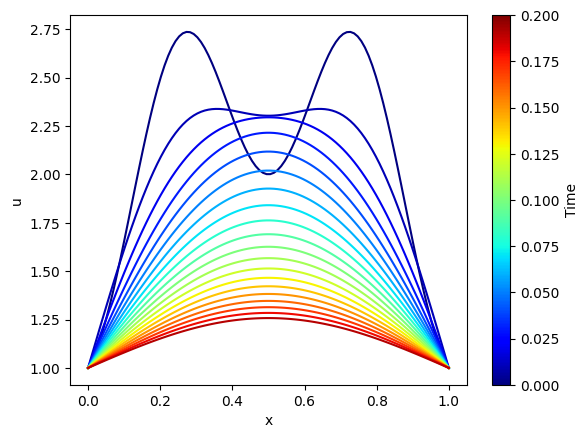

In [3]:
# Plot every 100th timestep
fig, ax = plt.subplots()
for n in range(0, Nt, 5000):
    color = cm.jet(n/Nt)
    ax.plot(x, u[:, n], color=color, label=f"t={t[n]:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("u")
norm = plt.Normalize(0, T)
cmap = cm.jet
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm)
cbar.ax.set_ylabel("Time")
plt.show()

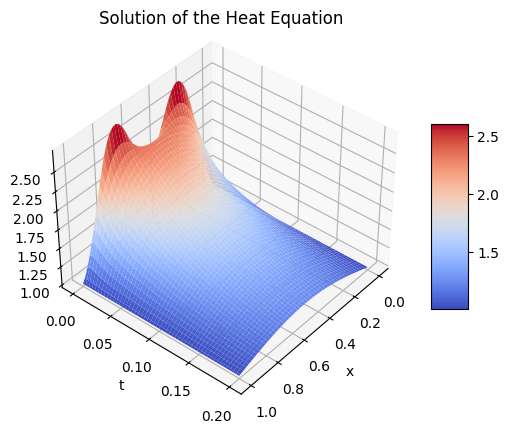

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 3D surface plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=40, azim=40)
X, Y = np.meshgrid(x, t[::100])
Z = u.T[::100, :]
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u')
ax.set_title('Solution of the Heat Equation')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

In [6]:
print(X.shape, Y.shape, Z.shape)

(1000, 100) (1000, 100) (1000, 100)


### Метод прогонки на примере схемы Кранка-Никольсон

Напомним __схему Кранка-Никольсон__ 

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=\frac{a}{2}\left(\frac{u_{m-1}^{n+1}-2 u_m^{n+1}+u_{m+1}^{n+1}}{h^2}+\frac{u_{m-1}^n-2 u_m^n+u_{m+1}^n}{h^2}\right)+f_m^n
$$

Хотим её реализовать. Пусть также заданы  начальные и граничные  условия:

$$
u_m^0=u_0(x_m)
$$

$$
u_0^n=u_{left}(t_n)
$$

$$
u_{N_x-1}^n=u_{right}(t_n)
$$

Хотим записать нашу разностную задачу в каноническом виде (для фиксированных $n$ и $n+1$ - по ним здесь суммирования не идёт)

$$
A_{sm} u_m^{n+1}=B_{sm} u_m^n+b_s^n
$$

где $A, B$ и $b$ пишутся исходя из вида уравнения. Перенесём все слагаемые с $n+1$ слоя влево:

$$
\left(1+\frac{a \tau}{h^2}\right) \cdot u_m^{n+1}-\frac{a \tau}{2 h^2} u_{m-1}^{n+1}-\frac{a \tau}{2 h^2} u_{m+1}^{n+1}=u_m^n+\frac{a \tau}{2h^2}\left(u_{m-1}^n-2 u_m^n+u_{m+1}^n\right)+\tau f_m^n
$$

Введём так называемое __число Куранта__ $r=\frac{a \tau}{2h^2}$. Тогда уравнение:

$$
\left(1+2r\right) \cdot  u_m^{n+1}-r \cdot  u_{m-1}^{n+1}-r \cdot u_{m+1}^{n+1}=u_m^n+r\cdot \left(u_{m-1}^n-2 u_m^n+u_{m+1}^n\right)+\tau f_m^n
$$

Откуда видим выражения на искомые операторы (c учётом граничных условий):

Оператор $A_{s, m}$:

$$
\quad
$$

$$
A_{0, 0} = 1, \quad
A_{N_x-1, N_x-1} = 1
$$

$$
A_{m-1, m} = -r , \quad
A_{m, m} = 1+2r, \quad
A_{m+1, m} = -r, \quad m \in[1, N_x-2]
$$

$$
A_{\text{other}, m} = 0
$$

$$
\quad
$$

$$
\mathbf{A} =
\begin{pmatrix}
1 & 0 & 0& 0 & \cdots & 0 & 0 \\
-r & 1+2r & -r & 0 & \cdots & 0 & 0 \\
0 & -r & 1+2r & -r & \cdots & 0 & 0 \\
0 & 0 & -r & 1+2r & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
0 & 0 & \cdots & 0 & -r & 1+2r & -r \\
0 & 0 & \cdots & 0 & 0 & 0 & 1 \\
\end{pmatrix}
$$

$$
\quad
$$

Оператор $B_{s, m}$ (при более сложных граничных условиях первая и последняя строчки могут быть ненулевыми):

$$
\quad
$$

$$
B_{m-1, m} = r , \quad
B_{m, m} = 1-2r, \quad
B_{m+1, m} = r, \quad m \in[1, N_x-2]
$$

$$
B_{\text{other}, m} = 0
$$

$$
\quad
$$

$$
\mathbf{B} =
\begin{pmatrix}
0 & 0 & 0 & 0 & \cdots & 0 & 0 \\
r & 1-2r & r & 0 & \cdots & 0 & 0\\
0 & r & 1-2r & r & \cdots & 0 & 0\\
0 & 0 & r & 1-2r & \cdots & 0 & 0\\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots\\
0 & 0 & \cdots & 0 & r & 1-2r & r\\
0 & 0 & \cdots & 0 & 0 & 0 & 0\\
\end{pmatrix}
$$

$$
\quad
$$

Столбец $b_s^n$:

$$
\quad
$$

$$
b_0^n=u_{\text{left}}(t_{n+1}), \quad
b_{N_x-1}^n=u_{\text{right}}(t_{n+1})
$$

$$
b_s^n=\tau \cdot f^n_s
$$

$$
\quad
$$

$$
\mathbf{b}^n =
\begin{pmatrix}
u_{\text{left}}(t_{n+1}) \\
\tau \cdot f_1^n \\
\tau \cdot f_2^n \\
\vdots \\
\tau \cdot f_{N_x-2}^n \\
u_{\text{right}}(t_{n+1}) \\
\end{pmatrix}
$$

$$
\quad
$$

На каждом шаге можно использовать np.linalg.solve относительно неизвестного столбца $u_s^{n+1}$, но это __плохо-обусловленная__ задача, т.е. при большой размерности ошибка решения СЛАУ станет слишком большой. 

Эффективнее использовать алгоритм __прогонки__.

Обозначим всю известную правую часть за столбец $F_s^n = B_{sm} u_m^n+b_s^n$. Тогда решаем систему на $u_m^{n+1}$:

$$
A_{sm} u_m^{n+1}=F_s^n 
$$

с трёхдиагональной матрицей $A$. Обозначим далее для простоты формул $x_i = u_i^{n+1}$.

Эта система равносильна следующим формулам (построчные равенства, там где вылезли за границы просто присваиваем нули):

$$
A_i x_{i-1}+B_i x_i+C_i x_{i+1}=F_i
$$

Ищем решение в виде реккуренты (т.е. перепишем задачу в терминах поиска коэффициентов $\alpha_i, \beta_i$ - как только они найдены, применяя эту же формулу найдём реккурентно все $x_i$):

$$
x_i=\alpha_{i+1} \cdot x_{i+1}+\beta_{i+1}, \quad \text { where } i=N_x-2, N_x-3, \ldots, 0
$$

При этом $\alpha_i, \beta_i$ __не должны__ зависеть искомых $x_i$. Начальные члены этих последовательностей можно определить нулевыми $\alpha_0=\beta_0=0$.

Используя это соотношение, выразим $x_{i-1}$ и $x_i$ через $x_{i+1}$ и подставим в изначальное уравнение:

$$
\left(A_i \alpha_i \alpha_{i+1}+B_i \alpha_{i+1}+C_i\right) \cdot x_{i+1}+A_i \alpha_i \beta_{i+1}+A_i \beta_i+B_i \beta_{i+1}-F_i=0
$$

Беря частную производную слева от $x_{i+1}$ понимаем, что множитель в скобках должен равняться нулю. А тогда и всё остальное в уравнении должно зануляться:

$$
\left\{\begin{array}{l}
A_i \alpha_i \alpha_{i+1}+B_i \alpha_{i+1}+C_i=0 \\
A_i \alpha_i \beta_{i+1}+A_i \beta_i+B_i \beta_{i+1}-F_i=0
\end{array}\right.
$$

Отсюда следуют явно заданные реккуренты на $\alpha_i, \beta_i$

$$
\left\{\begin{aligned}
\alpha_{i+1} & =\frac{-C_i}{A_i \alpha_i+B_i} \\
\beta_{i+1} & =\frac{F_i-A_i \beta_i}{A_i \alpha_i+B_i}
\end{aligned}\right.
$$

С начальным условием (из  $\alpha_0=\beta_0=0$):

$$
\left\{\begin{array}{l}
\alpha_1=-C_0 / B_0 \\
\beta_1=F_0 / B_0
\end{array}\right.
$$

Теперь, когда мы знаем $\alpha_i, \beta_i$, легко реккурентно посчитать искомый вектор неизвестных:

$$
\left\{\begin{array}{l}
x_i=\alpha_{i+1} x_{i+1}+\beta_{i+1}, \quad i=Nx-2 \ldots 0 \\
x_{Nx-1}=\cfrac{F_{Nx-1}-A_{Nx-1} \beta_{Nx-1}}{B_{Nx-1}+A_{Nx-1} \alpha_{Nx-1}}
\end{array}\right.
$$

100%|█████████████████████████████████████████████████████████████████████| 99/99 [00:00<00:00, 4274.35it/s]
/tmp/ipykernel_862/2029938125.py:120: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(sm)


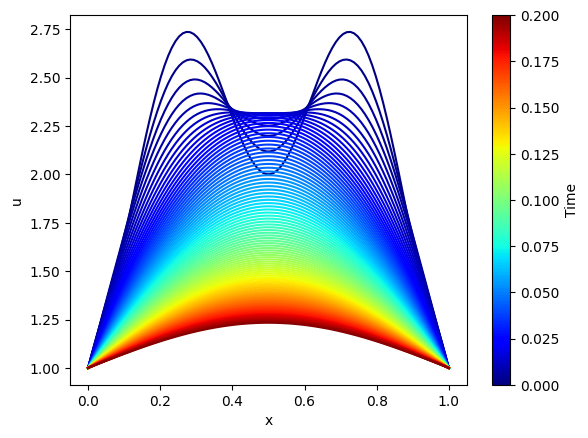

In [4]:
# Пример схемы Кранка-Никольсон с f = 0 

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from numba import njit
from tqdm import tqdm


def TDMA(A,B,C, F): # Прогонка
    # A, B, C, F - просто числовые последовательности, НЕ матрицы

    A = np.insert(A, 0, 0)
    
    n = len(F)
    x = np.zeros(n)
    alpha = np.zeros(n)
    beta = np.zeros(n)
    
    alpha[1] = -C[0]/B[0]
    beta[1] = F[0]/B[0]

    for i in range(2, n):
        alpha[i] = -C[i-1]/(A[i-1]*alpha[i-1] + B[i-1])
        beta[i] = (F[i-1] - A[i-1]*beta[i-1])/(A[i-1]*alpha[i-1] + B[i-1])
        

    x[n-1] = (F[n-1] - A[n-1]*beta[n-1])/(B[n-1] + A[n-1]*alpha[n-1])
    
    
    for i in range(n-1, 0, -1):  # помним, что последнее значение не кушает
        x[i - 1] = alpha[i]*x[i] + beta[i]
        
    
    return x

# Parameters
a = 1.0
L = 1.0
T = 0.2
Nx = 100
Nt = 100 # Как же мало нам понадобилось шагов по времени!
h = L/(Nx-1)
tau = T/(Nt-1)
x = np.linspace(0, L, Nx)
t = np.linspace(0, T, Nt)

# Initial and boundary conditions
def u0(x):
    return  1 + np.sin(2*np.pi*x/L)**2 + np.sin(np.pi*x/L)
def ul(t):
    return 1
def ur(t):
    return 1
# Define the source term
def f(t, x):
    return 0

# Initialize the solution matrix
u = np.zeros((Nt, Nx))

# Set the initial condition
u[0, :] = u0(x)

# Set the boundary conditions
u[:, 0] = ul(t)
u[:, -1] = ur(t)

# Set up the matrix for the Crank-Nicolson scheme
r = a*tau/(2*h**2)
A = np.zeros((Nx, Nx))
for i in range(1, Nx-1): # ПОмним, что последний индекс в цикле НЕ кушается
    A[i, i] = 1 + 2*r
    A[i, i-1] = -r
    A[i, i+1] = -r
A[0, 0] = 1
A[-1, -1] = 1

B = np.zeros((Nx, Nx))
for i in range(1, Nx-1): # ПОмним, что последний индекс в цикле НЕ кушается
    B[i, i] = 1 - 2*r
    B[i, i-1] = r
    B[i, i+1] = r


# Time stepping with the Crank-Nicolson scheme
for n in tqdm(range(1, Nt)):
    
    b = np.zeros(Nx)
    
    b[0] = ul(t[n])
    b[-1] = ur(t[n])
    b[1: -1] = tau*f(t[n-1], x[1:-1])
    
    #print(b)
    
    F = B @ u[n-1] + b

    #u[n, :] = np.linalg.solve(A, F) # Не сработает для большого Nx
    u[n, :] = TDMA(A.diagonal(offset = -1),
                     A.diagonal(offset = 0),
                     A.diagonal(offset = 1),
                     F)

    
# Plot every 100th timestep
fig, ax = plt.subplots()
for n in range(0, Nt, 1):
    color = cm.jet(n/Nt)
    ax.plot(x, u[n, :], color=color, label=f"t={t[n]:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("u")
norm = plt.Normalize(0, T)
cmap = cm.jet
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm)
cbar.ax.set_ylabel("Time")
plt.show()


### Построение схем для переменных коэффициентов (консерватизм) 

__Определение.__ Схема называется __консервативной__, если в дискретизованной задаче выполняются те же законы сохранения (первые интегралы), что и в дифференциальной.

__Примечание.__ Вспомните про количество независимых первых интегралов в системе ДУ. 

Как правило, если коэффициенты в линейном УРЧП зависят от координат $a=a(x, t)$, то для обеспечения консерватизма системы необходимо __строить разностную задачу исходя из требуемых законов сохранения__

На примере того же однородного уравнения диффузии (теплопроводности)

$$
\frac{\partial u}{\partial t}=a \frac{\partial^2 u}{\partial x^2}, \quad t \in[0, \mathrm{~T}], \quad x \in[0, X]
$$

Его законом сохранения (первым интегралом) является уравнение непрерывности на тепловой поток $W=-a(t, x) \frac{\partial u}{\partial x}$:

$$
\frac{\partial u}{\partial t}+\frac{\partial W}{\partial x}=0
$$

или, в интегральной форме,

$$
\int_S\left(\frac{\partial u}{\partial t}+\frac{\partial W}{\partial x}\right) d t d x=\oint_{\Gamma} u d x-W d t=0
$$

Любое из этих уравнений должно быть выполнено всегда и где угодно. Удобно взять самое последнее и обеспечить его для самого маленького контура в системе (для любого другого контура оно будет выполнено автоматически по линейности):

$$
u_m^n \cdot h-W_{m+1 / 2}^{n+1 / 2} \cdot \tau-u_m^{n+1} \cdot h+W_{m-1 / 2}^{n+1 / 2} \cdot \tau=0
$$

Это же можно получить из дифференциальной формы закона сохранения

$$
\frac{u_m^{n+1}-u_m^n}{\tau}+\frac{W_{m+1 / 2}^{n+1 / 2}-W_{m-1 / 2}^{n+1 / 2}}{h}=0
$$


Здесь взяли __промежуточные узлы__ на $W$, т.к. такой приём, как правило, даёт лучшую устойчивость __при переменных коэффициентах__ (напоминаю $W=-a(t, x) \frac{\partial u}{\partial x}$):

$$
W_{m+1 / 2}^{n+1 / 2}=-\frac{1}{2}\left(a_{m+1 / 2}^n \frac{u_{m+1}^n-u_m^n}{h}+a_{m+1 / 2}^{n+1} \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}\right)
$$

$$
W_{m-1 / 2}^{n+1 / 2}=-\frac{1}{2}\left(a_{m-1 / 2}^n \frac{u_{m}^n-u_{m-1}^n}{h}+a_{m-1 / 2}^{n+1} \frac{u_{m}^{n+1}-u_{m-1}^{n+1}}{h}\right)
$$

Подставляя это в дискретизованный закон сохранения, имеем нашу __консервативную__ численную схему:

$$
\begin{aligned}
& \quad \frac{u_m^{n+1}-u_m^n}{\tau}-\frac{1}{2 h}\left[\left(a_{m+1 / 2}^n \frac{u_{m+1}^n-u_m^n}{h}-a_{m-1 / 2}^n \frac{u_m^n-u_{m-1}^n}{h}\right)+\right. \\
& \left.+\left(a_{m+1 / 2}^{n+1} \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}-a_{m-1 / 2}^{n+1} \frac{u_m^{n+1}-u_{m-1}^{n+1}}{h}\right)\right]=0
\end{aligned}
$$

Она получилось шеститочечной.

__Примечание.__ В случае неоднородности просто добавляем её. Опять же, чем на бОльших узлах зададим, тем лучше, но не очень критично, если честно.

$$
\begin{aligned}
& \quad \frac{u_m^{n+1}-u_m^n}{\tau}-\frac{1}{2 h}\left[\left(a_{m+1 / 2}^n \frac{u_{m+1}^n-u_m^n}{h}-a_{m-1 / 2}^n \frac{u_m^n-u_{m-1}^n}{h}\right)+\right. \\
& \left.+\left(a_{m+1 / 2}^{n+1} \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}-a_{m-1 / 2}^{n+1} \frac{u_m^{n+1}-u_{m-1}^{n+1}}{h}\right)\right]=f_m^n
\end{aligned} 
$$

КОД

### Квазилинейный случай

Рассмотрим случай зависимости коэффициентов от от искомой функции $a=a(u)>0$ и $f=f(u)$ - т.е. простая квазилинейность. При зависимости этих коэффициентов ещё и от $x, t$ обобщение тривиально на основе предыдущего пункта.

Т.к. коэффициенты переменные, то опять-таки используем __промежуточные узлы__.

- Явная схема с нелинейностью на нижнем слое

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=\frac{1}{h}\left[a_{m+1 / 2}^n \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}-a_{m-1 / 2}^n \frac{u_m^{n+1}-u_{m-1}^{n+1}}{h}\right]+f_m^n
$$

где $a_{m+1 / 2}^n$ может быть вычислена одним из следующим способов:

1. $a_{m+1 / 2}^n=\frac{1}{2}\left(a\left(u_m^n\right)+a\left(u_{m+1}^n\right)\right)$,

2. $a_{m+1 / 2}^n=a\left(\cfrac{u_m^n+u_{m+1}^n}{2}\right)$,

3. $a_{m+1 / 2}^n=a\left(\cfrac{2 u_m^n u_{m+1}^n}{u_m^n+u_{m+1}^n}\right)$,

4. $a_{m+1 / 2}^n=\cfrac{2 a\left(u_m^n\right) a\left(u_{m+1}^n\right)}{a\left(u_m^n\right)+a\left(u_{m+1}^n\right)}$.

На следующем слое опять-таки решается СЛАУ на неизвестные коэффициенты методом прогонки (полученная система будет трёхдиагональной).

Недостаток схемы заключается в необходимости выполнения условия, ограничивающего шаг по времени $\tau\left\|f_u^{\prime}\right\|<<1$ для обеспечения устойчивости.

- Неявная схема с нелинейностью на нижнем слое

$$
\frac{u_m^{n+1}-u_m^n}{\tau}=\frac{1}{h}\left(a_{m+1 / 2}^{n+1} \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}-a_{m-1 / 2}^{n+1} \frac{u_m^{n+1}-u_{m-1}^{n+1}}{h}\right)+f_m^{n+1}
$$

Нужна когда условие $\tau\left\|f_u^{\prime}\right\|<<1$ невыполнимо.



Решать большую систему нелинейных уравнений ну уж очень не хочется, так что здесь, как правило, используют линеаризацию

$$
f\left(u_m^{i+1}\right)=f\left[u_m^i+\left(u_m^{i+1}-u_m^i\right)\right] \approx f\left(u_m^i\right)+f_u^{\prime}\left(u_m^i\right)\left(u_m^{i+1}-u_m^i\right)
$$


$$
a\left(u_m^{i+1}\right)=a\left[u_m^i+\left(u_m^{i+1}-u_m^i\right)\right] \approx a\left(u_m^i\right)+a_u^{\prime}\left(u_m^i\right)\left(u_m^{i+1}-u_m^i\right)
$$

И алгоритм тот же самый - решить СЛАУ на верхнем уровне методом прогонки.

__Примечание.__ В случае общей квазилинейности по $a=a(u, x, t)$ просто берём предыдущий параграф и всё, что связано с зависимостью от $u$ считаем по формулам из этого. Шеститочечная схема, например:

$$
\begin{aligned}
& \frac{u_m^{n+1}-u_m^n}{\tau}-\frac{1}{2 h}\left[\left(a_{m+1 / 2}^n \frac{u_{m+1}^{n+1}-u_m^{n+1}}{h}-a_{m-1 / 2}^n\frac{u_m^{n+1}-u_{m-1}^{n+1}}{h}\right)+\right. \\
& \left.+\left(a_{m+1 / 2}^n \frac{u_{m+1}^n-u_m^n}{h}-a_{m-1 / 2}^n \frac{u_m^n-u_{m-1}^n}{h}\right)\right] =f\left(u_m^n\right)+f_u^{\prime}\left(u_m^n\right)\left(u_m^{n+1}-u_m^n\right)
\end{aligned}
$$

где $a_{m+1 / 2}^n$ может быть вычислена одним из следующим способов:

1. $a_{m+1 / 2}^n=\frac{1}{2}\left(a\left(u_m^n, \; x_m, \;t_n\right)+a\left(u_{m+1}^n, \; x_{m+1}, \;t_n\right)\right)$,

2. $a_{m+1 / 2}^n=a\left(\cfrac{u_m^n+u_{m+1}^n}{2},\; \cfrac{x_m+x_{m+1}}{2},\; t_n\right)$,

3. $a_{m+1 / 2}^n=a\left(\cfrac{2 u_m^n u_{m+1}^n}{u_m^n+u_{m+1}^n},\; \cfrac{2 x_m x_{m+1}}{x_m+x_{m+1}}, \; t_n\right)$,

4. $a_{m+1 / 2}^n=\cfrac{2 \cdot a_m^n \cdot a_{m+1}^n}{a_m^n+a_{m+1}^n}$.

### Многомерный  (по координате) случай

Численное решение даже простейших уравнений параболического типа сильно усложняется, если в задаче имеется в наличии более одного пространственного измерения. Условие устойчивости для многомерных схем накладывает столь жесткие ограничения на шаги по времени, что расчет по ним практически невозможен (на прошлом семинаре мы как раз использовали явную схему - работало всё очень долго). Необходимо применять __неявные схемы__. 

Пусть решаем

$$
\frac{\partial u}{\partial t}=\frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2} + f(x, y, t)
$$

Неоднородностью $f(x, y, t)$ пока пренебрежём (см. примечание в конце пункта).

Дискретизуем задачу в виде

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\mathbf{\Lambda}_1 u_{m l}^{n+1}+\mathbf{\Lambda}_2 u_{m l}^{n+1}
$$

где 

$$
\mathbf{\Lambda}_1 u_{m l}^{n+1}=\frac{u_{m-1, l}^{n+1}-2 u_{m, l}^{n+1}+u_{m+1, l}^{n+1}}{h_x^2}
$$

$$
\mathbf{\Lambda}_2 u_{m l}^{n+1}=\frac{u_{m, l-1}^{n+1}-2 u_{m l}^{n+1}+u_{m, l+1}^{n+1}}{h_y^2}
$$

Схема выглядит следующим образом:



<img src="https://cdn.mathpix.com/snip/images/FJHOqGofKfhY-XPw7r0mmRTtFRRzh6D9Qj0m0PvWy14.original.fullsize.png" width="400">

Можно на каждом шаге решать систему на весь следующий слой точно так же, как мы это делали на прошлом семинаре с прямым решением эллиптического уравнения, но, как мы уже знаем, это не очень эффективно и очень необусловлено.

Можно предложить схему __расщепления по направлениям__, или локально одномерную схему (__метод дробных шагов__), где на каждом шаге по времени мы последовательно решаем две разностные задачи сначала на ~, потом на $n+1$:

$$
\frac{\tilde{u}_{m l}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1 \tilde{u}_{m l}
$$

$$
\frac{u_{m l}^{n+1}-\tilde{u}_{m l}}{\tau}=\mathbf{\Lambda}_2 u_{m l}^{n+1}
$$

<img src="https://cdn.mathpix.com/snip/images/f7rGZA0niueT2LKUSXckgkxXhZed9DKWCNl54OhXA7Q.original.fullsize.png" width="400">

На каждом из промежуточных шагов мы сути решаем одномерную задачу для строки или столбца матрицы $u_{ml}$ столько раз, чтобы всю её заполнить. Сначала делаем в одном направлении (по одной координате), потом в другом (по другой координате). Таким образом применим хорошо обусловленный алгоритм прогонки.

Порядок аппроксимации этой схемы $O\left(\tau, h_x^2, h_y^2\right)$.

__Примечание.__ Обобщение на бОльшие размерности тривиально - просто больше промежуточных слоёв.


__Примечание.__ Порядок аппроксимации по времени легко увеличить до второго, придав слою ~ смысл $n+\frac{1}{2}$ шага по времени:

$$
\begin{aligned}
& \frac{u_{m l}^{n+1 / 2}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1\left[\xi u_{m l}^{n+1 / 2}+(1-\xi) u_{m l}^n\right] \\
& \frac{u_{m l}^{n+1}-u_{m l}^{n+1 / 2}}{\tau}=\boldsymbol{\Lambda}_2\left[\xi u_{m l}^{n+1}+(1-\xi) u_{m l}^{n+1 / 2}\right]
\end{aligned}
$$

__Примечание.__ Если уравнение неоднородно, то правую часть легко засунуть в схему, например:

$$
\frac{\tilde{u}_{m l}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1 \tilde{u}_{m l}+\frac{1}{2} f_{m l}^n
$$

$$
\frac{u_{m l}^{n+1}-\tilde{u}_{m l}}{\tau}=\boldsymbol{\Lambda}_2 u_{m l}^{n+1}+\frac{1}{2} f_{m l}^{n+\frac{1}{2}}
$$

КОД

## Сходимость численных схем (параболика)
### Сходимость = Аппроксимация + Устойчивость

__Теорема.__ (Лакса-Рябенького-Филиппова). Пусть разностная задача аппроксимирует дифференциальную задачу на ее решении и устойчива. Тогда решение разностной задачи сходится к решению дифференциальной. 
Если аппроксимация имеет порядок $k$ по времени и порядок $p$ по пространству, то и сходимость имеет те же порядки.

Простые примеры приводились на прошлом занятии.

### Примеры исследования на устойчивость многомерных схем спектральным признаком

Формулировка спектрального признака была дана на прошлом семинаре. Тут же применим его для схем на однородное уравнение теплопроводности (диффузии).

- __Явная схема__

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\frac{u_{m-1, l}^n-2 u_{m l}^n+u_{m+1, l}^n}{h_x^2}+\frac{u_{m, l-1}^n-2 u_{m l}^n+u_{m, l+1}^n}{h_y^2}
$$

или, в операторном виде,

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1 u_{m l}^n+\boldsymbol{\Lambda}_2 u_{m l}^n
$$


Подставим в это уравнение следующую штуку

$$
u_{m l}^n=\lambda^n e^{i \alpha m+i \beta l}, \quad \alpha, \beta \in[0,2 \pi]
$$

Сокращая всё, что сокращается, выражаем $\lambda$:

$$
\lambda\left(\alpha, \beta, \tau, h_x, h_y\right)=1-4 \frac{\tau}{h_x^2} \sin ^2 \frac{\alpha}{2}-4 \frac{\tau}{h_y^2} \sin ^2 \frac{\beta}{2}
$$

Дальше надо посмотреть, при каких параметрах $\tau, h_x, h_y$ все наши $\lambda$ (тут получилось только одна лямбда) по модулю не превосходят единицу __равномерно__ по $\alpha$ и $\beta$. Здесь, очевидно,

$$
\tau \leq \frac{1}{2\left(h_x^{-2}+h_y^{-2}\right)}
$$

- __Неявная схема__

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\frac{u_{m-1, l}^{n+1}-2 u_{m l}^{n+1}+u_{m+1, l}^{n+1}}{h_x^2}+\frac{u_{m, l-1}^{n+1}-2 u_{m l}^{n+1}+u_{m, l+1}^{n+1}}{h_y^2}
$$

или, в операторном виде,

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1 u_{m l}^{n+1}+\boldsymbol{\Lambda}_2 u_{m l}^{n+1}
$$

Подставим сюда

$$
u_{m l}^n=\lambda^n e^{i \alpha m+i \beta l}, \quad \alpha, \beta \in[0,2 \pi]
$$

И выразим лямбду

$$
\lambda=\frac{1}{1+4 \frac{\tau}{h_x^2} \sin ^2 \frac{\alpha}{2}+4 \frac{\tau}{h_y^2} \sin ^2 \frac{\beta}{2}}
$$

Видим, что эта лямбда по модулю меньше единицы равномерно по $\alpha$ и $\beta$ при любых $\tau, h_x, h_y$, т.е. она абсолютно устойчива.

- __Схема расщепления по направлению__

В этой схеме последовательно решаем задачи сначала на ~, потом на $n+1$.

$$
\frac{\tilde{u}_{m l}-u_{m l}^n}{\tau}=\mathbf{\Lambda}_1 \tilde{u}_{m l}
$$

$$
\frac{u_{m l}^{n+1}-\tilde{u}_{m l}}{\tau}=\boldsymbol{\Lambda}_2 u_{m l}^{n+1}
$$

По алгоритму применения спектрального признака, надо подставить

$$
u_{m l}^n=\lambda^n e^{i \alpha m+i \beta l}, \quad \alpha, \beta \in[0,2 \pi]
$$

где явно записан множитель временной эволюции $\lambda^n$.

При переходе на слой ~ тоже аля происходит временная эволюция, поэтому

$$
\tilde{u}_{m l}=\lambda_1 u_{m l}^n
$$

То же верно при переходе со слоя ~ на $n+1$:

$$
u_{m l}^{n+1}=\lambda_2 \tilde{u}_{m l}=\left(\lambda_1 \lambda_2\right) u_{m l}^n
$$

Откуда $\lambda=\lambda_1 \lambda_2$.

Подставим формулы выше в разностные схемы и сократим всё, что сокращается. Итого,

$$
\lambda_1=\frac{1-4 \frac{\tau}{h_x^2} \sin ^2 \frac{\alpha}{2}}{1+4 \frac{\tau}{h_y^2} \sin ^2 \frac{\beta}{2}}, \quad \lambda_2=\frac{1-4 \frac{\tau}{h_x^2} \sin ^2 \frac{\beta}{2}}{1+4 \frac{\tau}{h_y^2} \sin ^2 \frac{\alpha}{2}}
$$

Окончательный спектр оператора послойного перехода

$$
\lambda\left(\alpha, \beta, \tau, h_x, h_y\right)=\lambda_1 \lambda_2=\frac{\left(1-4 \frac{\tau}{h_x^2} \sin ^2 \frac{\alpha}{2}\right)\left(1-4 \frac{\tau}{h_x^2} \sin ^2 \frac{\beta}{2}\right)}{\left(1+4 \frac{\tau}{h_y^2} \sin ^2 \frac{\alpha}{2}\right)\left(1+4 \frac{\tau}{h_y^2} \sin ^2 \frac{\beta}{2}\right)}
$$

Легко видим, что эта штука всегда меньше единицы. Т.е. схема безусловно устойчива.

__Примечание.__ В случае переменных коэффициентов можно использовать __принцип замороженных коэффициентов__ - когда мы считаем коэффициенты константными даже при их непостоянности. Часто приводит к неверным результатам, но существенно упрощает выкладки. В остальном же придётся делать оценку устойчивости равномерно по всей области допустимых параметров $t, x, y$.

### Пример исследования на аппроксимацию схемы расщепления по направлению

Для последней схемы покажем, как определить порядок аппроксимации.

В этой схеме последовательно решаем задачи сначала на ~, потом на $n+1$.

$$
\frac{\tilde{u}_{m l}-u_{m l}^n}{\tau}=\mathbf{\Lambda}_1 \tilde{u}_{m l}
$$

$$
\frac{u_{m l}^{n+1}-\tilde{u}_{m l}}{\tau}=\boldsymbol{\Lambda}_2 u_{m l}^{n+1}
$$

Хотим всё свести к одному уравнению, члены в котором легко разложить в Тейлора.

Запишем эти уравнения в следующем виде:

$$
\left(\mathbf{E}-\tau \mathbf{\Lambda}_1\right) \tilde{u}_{m l}=u_{m l}^n
$$

$$
\left(\mathbf{E}-\tau \boldsymbol{\Lambda}_2\right) u^{n+1}=\tilde{u}_{m l}
$$

Подействуем на обе части второго уравнения оператором $\left(\mathbf{E}-\tau \mathbf{\Lambda}_1\right)$:
$$
\begin{aligned}
& \quad\left(\mathbf{E}-\tau \mathbf{\Lambda}_1\right)\left(\mathbf{E}-\tau \mathbf{\Lambda}_2\right) u_{m l}^{n+1}=\left(\mathbf{E}-\tau \mathbf{\Lambda}_1\right) \tilde{u}_{m l}
\end{aligned}
$$

Так как $\left(\mathbf{E}-\tau \mathbf{\Lambda}_1\right) \tilde{u}_{m l}=u_{m l}^n$, то

$$
\left(\mathbf{E}-\tau \boldsymbol{\Lambda}_1\right)\left(\mathbf{E}-\tau \boldsymbol{\Lambda}_2\right) u_{m l}^{n+1}=u_{m l}^n
$$

Раскрывая скобки,

$$
\frac{u_{m l}^{n+1}-u_{m l}^n}{\tau}=\boldsymbol{\Lambda}_1 u_{m l}^{n+1}+\boldsymbol{\Lambda}_2 u_{m l}^{n+1}-\tau^2 \boldsymbol{\Lambda}_1 \boldsymbol{\Lambda}_2 u_{m l}^{n+1}
$$

И здесь уже всё разлагаем в Тейлора. Порядок аппроксимации этой схемы $O\left(\tau, h_x^2, h_y^2\right)$.

## Домашнее задание

__Задача 1.__

Построить две разностные схемы для задачи c разными шаблонами
$$
\frac{\partial u}{\partial t}-a^2(x, t) \frac{\partial^2 u}{\partial x^2}=0, \quad u(x, 0)=\psi(x),
$$
Спектральным признаком исследовать полученные схемы на устойчивость, используя принцип замороженных коэффициентов.

Решить задачу, используя полученные схемы.

__Задача 2.__

Определить параметры сетки для достижения точности $\varepsilon=10^{-4}$ при численном решении задачи
$$u_t=u_{x x}+\left(4 x /\left(x^2+2 t+1\right)\right) u_x, \quad 0 \leq x \leq 1, \quad 0<t$$

$$u(0, t)=1 /(2 t+1), \quad u(1, t)=1 /(2(t+1)) , \quad u(x, 0)=1 /\left(x^2+1\right), \quad 0 \leq x \leq 1$$

Да, задачу нужно решить численно. Погрешность оценивайте итеративно уменьшая шаги в 2 раза и смотрите сходимость полученных решений. Как только разность между двумя последовательными решениями будет меньше $\varepsilon=10^{-4}$ в точках где оба решения определены, считайте, что вы получили ответ.

__Задача 3.__

Исследовать на устойчивость и аппроксимацию трехслойную схему $\frac{1.5\left(y_m^{n+1}-y_m^n\right)}{\tau}-\frac{0.5\left(y_m^n-y_m^{n-1}\right)}{\tau}=\boldsymbol{\Lambda}_{x x} y_m^{n+1}$ с шаблоном

![original image](https://cdn.mathpix.com/snip/images/hrJsWlZ-nfJtF4ZGY4n-ziwfd3cWo-TZuPerGA02bLg.original.fullsize.png)

__Задача 4.*__

В файле Задача_4.pdf  